In [5]:
import sys
sys.path.append("../src")
sys.path.insert(0, "/Users/bohaoli/Desktop/tuto/tuto_langchain/official/langchain-langgraph-langsmith/utils")

from utils import ppm, ppms, debug

In [6]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🔬 Research Agent — 单 agent 的研究循环

**一句话定位**:用 **ReAct 循环 + Tavily 搜索** 让 agent 替你做研究,关键点是 **不让它无限调用工具**。

</div>

> *研究的目标 = 收集 research brief 里要求的 context。*

整体研究流程图:

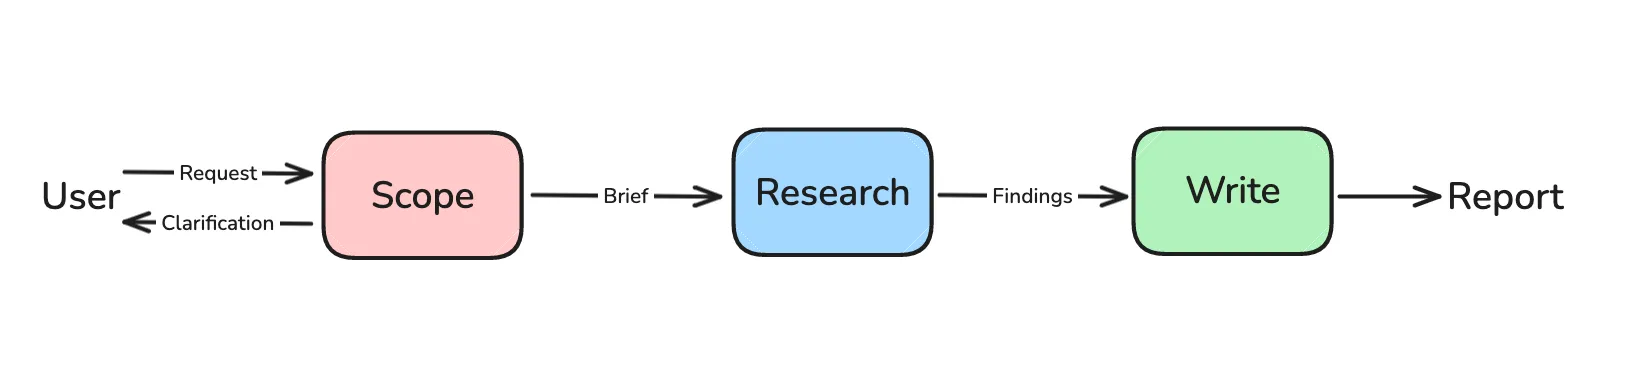

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🤔 为什么 research 任务最适合用 agent?**

研究是 **开放性任务** —— 最佳策略 **事先不可知**。看两个例子:

| 请求 | 适合的策略 |
|------|----------|
| 「**对比这两个产品**」 | 各搜一遍 → 综合对比 |
| 「**给我招聘的 top 候选人**」 | 开放性搜 → 综合 + 排序 |

不同请求需要不同搜索深度。[Agent](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) 适合这种任务,**因为它能根据中间结果灵活调整策略**。

</div>

### 📋 Agent 的 4 个核心节点

| 节点 | 干什么 |
|------|--------|
| **LLM Decision Node** | 分析当前状态 → 决定调工具 or 给最终回复 |
| **Tool Execution Node** | 执行搜索工具(LLM 觉得还要更多信息时) |
| **Research Compression Node** | **压缩** 研究发现,精简后续处理 |
| **Routing Logic** | 根据 LLM 决定继续 or 终止循环 |

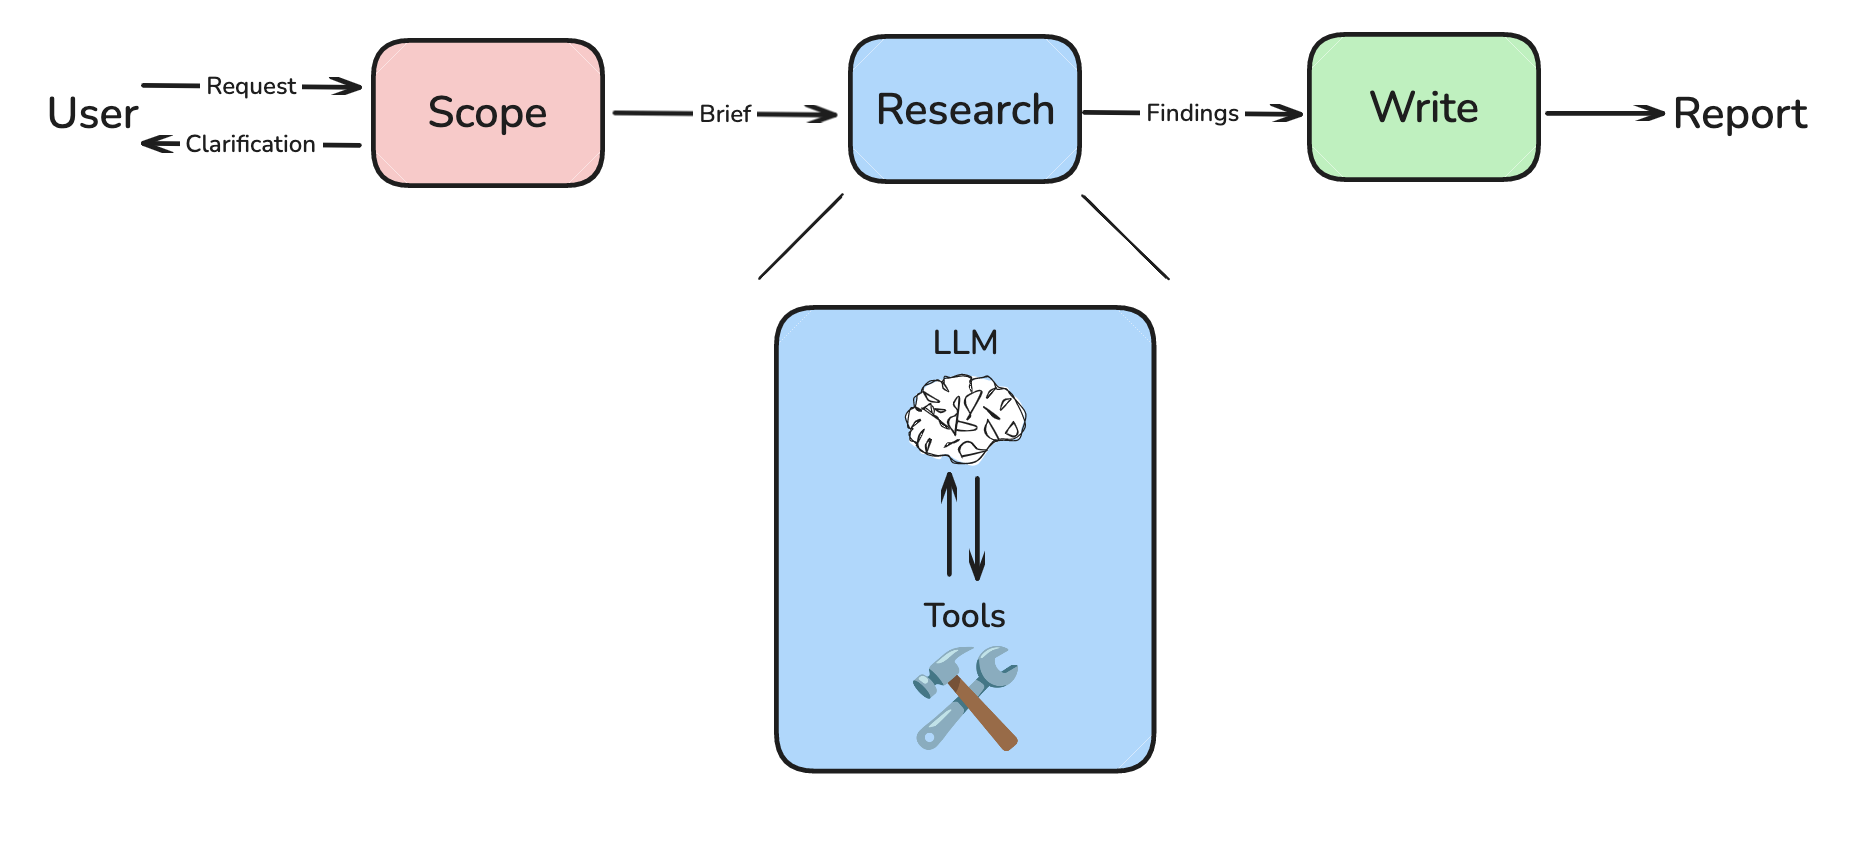

### 📝 Prompt 设计

定义 prompt 指导 agent 用搜索工具。为了 **防止过度搜索 / 保持研究聚焦**,用 [几个 agent prompt 技巧](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

### ① 像 agent 一样思考

你怎么指导一个新同事?同样指导 agent:

- **仔细读问题** — 用户具体需要什么信息?
- **从宽泛搜索开始** — 先用全面、宽泛的 query
- **每次搜完暂停评估** — 信息够答了吗?还缺什么?
- **逐渐细化搜索** — 边搜集信息边填补空白

### ② 给具体启发(防止「**搜索失控**」)

用 **硬性限制** 阻止 agent 过度调用工具:

| 限制 | 含义 |
|------|------|
| **能自信回答就停** | 别追求完美 |
| **设预算** | 简单 query 用 2-3 次搜索;复杂 query 最多 5 次 |
| **绝对上限 5 次** | 找不到也得停 |

### ③ 展示思考过程

每次搜完调一次 [`think_tool` 分析结果](https://www.anthropic.com/engineering/claude-think-tool):

| 自问 | 决策点 |
|------|--------|
| 我找到的关键信息是什么? | 总结 |
| 还缺什么? | 评估完整性 |
| 够回答了吗? | 决定终止 |
| 应该再搜还是直接给答案? | 走向下一步 |

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 三个技巧的化学反应**

**没有这些技巧时的 agent 表现**:

```
"best coffee shops SF" → "Saint Frank Coffee details" → "Sightglass Coffee details"
→ "Ritual Coffee details" → ... (20+ 次搜索)
```

**有了之后**:

```
"best coffee shops SF" → ThinkTool(分析) → "SF specialty coffee quality ratings"
→ ThinkTool(评估完整性) → 给答案(总共 3-5 次搜索)
```

**核心洞察**:**「**像一个时间有限的人类研究员一样思考**」** —— 这能避免「**搜索失控**」(agent 无限搜下去)的问题。

</div>

In [7]:
from utils import show_prompt
from deep_research_from_scratch.prompts import research_agent_prompt
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

### 📦 State 和 Schemas

创建 agent 的 state 对象。

In [8]:
%%writefile ../src/deep_research_from_scratch/state_research.py

"""
State Definitions and Pydantic Schemas for Research Agent

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """
    State for the research agent containing message history and research metadata.
    
    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    Output state for the research agent containing final research results.
    
    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

Overwriting ../src/deep_research_from_scratch/state_research.py


### 🔧 定义研究工具

### 🌐 Tavily SDK 集成

我们用 [Tavily SDK](https://docs.tavily.com/sdk/python/reference) 做网页搜索。

Tavily 是为 **AI 应用优化** 的搜索引擎,免费额度也很足。功能:

| 能力 | 说明 |
|------|------|
| 实时网页搜索 | live web results |
| 内容提取 + 摘要 | 自动 clean |
| 域名过滤 + 结果排序 | 精控来源 |
| 异步支持 | 性能 |

### 🔄 替代方案

虽然本课用 Tavily,**还有几个优秀替代**:

| 工具 | 特点 |
|------|------|
| **[Tavily Extract](https://docs.tavily.com/documentation/api-reference/endpoint/extract)** | 专门的提取 endpoint,从指定 URL 提内容(不搜) |
| **[Jina Reader](https://jina.ai/reader/)** | 最简单 — URL 前加 `https://r.jina.ai/` 就转成 LLM 友好文本 |
| **[Firecrawl](https://www.firecrawl.dev/)** | 全能爬虫平台,支持 JS 渲染、sitemap 爬 |

**各有所长**:Tavily 适合 search-first,Jina 最简单,Firecrawl 最全能。

### 🛠️ LangChain Tools

用 `@tool` 装饰器把 Tavily 搜索函数 **转成 [LangChain tool](https://python.langchain.com/docs/concepts/tools/)**:

| 好处 | 说明 |
|------|------|
| 自动生成 schema | 给 LLM 看 |
| 跟 LangChain agent 框架集成 | 现成的 |
| 标准化 tool calling | 一致接口 |
| 类型校验 + 自动文档 | 减 bug |

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 注意 [`InjectedToolArg`](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.base.InjectedToolArg.html)**

某些参数标了 `InjectedToolArg` —— 这些参数 **不会出现在给 LLM 的 schema 里**,**只在执行时由我们注入**。

**好处**:可以注入 runtime 值(比如 api_key、user_id),**LLM 不需要管这些细节**,降低出错概率。

📎 工具类型详见 [`/project-002-ambiant-agents/notebooks/0_c_⭐️_工具类型大全.ipynb`](../../project-002-ambiant-agents/notebooks/0_c_⭐️_工具类型大全.ipynb)

</div>

In [9]:
%%writefile ../src/deep_research_from_scratch/utils.py

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from tavily import TavilyClient

from deep_research_from_scratch.state_research import Summary
from deep_research_from_scratch.prompts import summarize_webpage_prompt

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        List of search result dictionaries
    """
    
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.
    
    Args:
        search_results: List of search result dictionaries
        
    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.
    
    Args:
        unique_results: Dictionary of unique search results
        
    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """Format search results into a well-structured string output.
    
    Args:
        summarized_results: Dictionary of processed search results
        
    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    
    formatted_output = "Search results: \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output

# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption
    return format_search_output(summarized_results)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.
    
    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.
    
    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    
    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?
    
    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps
        
    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

Overwriting ../src/deep_research_from_scratch/utils.py


### 🤖 Research Agent — 核心实现

### 📋 概览

我们的 research agent 通过 **迭代式 tool-calling** 搜索信息。

agent 的 4 节点模式:

| 节点 | 职责 |
|------|------|
| **LLM Decision Node** | 决定调工具 or 给最终回复 |
| **Tool Execution Node** | 执行搜索 |
| **Research Compression Node** | 压缩 findings(关键!)|
| **Routing Logic** | 控制流 |

### 🎯 Context Engineering 策略

按 [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/) 的原则,我们在 **两个位置** 应用 context engineering:

### ① 网页内容摘要

**问题**:原始搜索结果常含大量噪音(导航栏、广告、模板)。

`summarize_webpage_content()` 函数干这些:

- 用 structured output **提取关键信息和相关摘录**
- **过滤无关内容**,保留事实细节
- **压缩冗长文章** 成聚焦摘要
- **保留来源归属** 便于核查

### ② Research Result 压缩

**问题**:agent 多次搜索后,**对话 context 急速增长**。

`compress_research()` 函数干这些:

- **综合多个工具调用的发现** 成连贯洞察
- **提取 raw notes** 用于详细分析,同时维护压缩摘要
- **减少后续 LLM 调用的 token 消耗**
- **保留报告写作必需的信息**

这种 **双层 context engineering** 让 agent 高效处理大量信息,**同时保持高质量产出**。

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 ③ 小心做压缩(这步**最危险**)**

[压缩有风险](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus)([见 Cognition 的警告](https://cognition.ai/blog/dont-build-multi-agents))!**容易丢失有价值的信息**。

我们用 LLM 做压缩,但有 **特别设计**:

- system prompt 写在 **多个 tool calls 的长 trajectory 之前**
- 但长 context 可能让压缩 LLM [**遗忘任务指令**](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html),导致泛泛而谈、丢信息

**所以我们加了一条 `compress_research_human_message`** 强化任务:

- **再次明确** 原始研究主题
- **提醒** 保留所有跟问题相关的信息
- **强调** 完整 findings 对最终报告的重要性
- **防止** 压缩阶段任务漂移

</div>

### ④ Output Token 管理

研究压缩可能产出很长内容。**必须确保不超 model token 限制**,否则会被截断(经常看到「**Sextant Coffee Ro**...」这种突然断尾就是这个问题)。

参考容量:

| 模型 | output token 上限 |
|------|-----------------|
| [GPT-4.1](https://openai.com/index/gpt-4-1/) | 高达 **33k** |
| [Claude 4 Sonnet](https://www.anthropic.com/claude/sonnet) | **64k** |

⚠️ SDK / LangChain 集成可能 **默认设了更低的上限**(例如 [Claude 默认 1024 tokens](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15))。**显式设大 `max_tokens`** 才能保完整输出。

### 📊 模型对比(压缩任务上的延迟)

| 模型 | 延迟 | trace |
|------|------|-------|
| **Claude4-Sonnet** | 99s | [trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r) |
| **GPT-4.1** | 38s | [trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r) |

测试压缩质量 vs 延迟,选适合的模型。

In [15]:
%%writefile ../src/deep_research_from_scratch/research_agent.py

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model

from deep_research_from_scratch.state_research import ResearcherState, ResearcherOutputState
from deep_research_from_scratch.utils import tavily_search, get_today_str, think_tool
from deep_research_from_scratch.prompts import research_agent_prompt, compress_research_system_prompt, compress_research_human_message

# ===== CONFIGURATION =====

# Set up tools and model binding
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize models
# model = init_chat_model(model="anthropic:claude-sonnet-4-6")
model = init_chat_model(model="anthropic:claude-sonnet-4-6")
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
compress_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-6", max_tokens=64000

# ===== AGENT NODES =====

def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
 
    # Execute all tool calls
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
            
    # Create tool message outputs
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # If the LLM makes a tool call, continue to tool execution
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we have a final answer
    return "compress_research"

# ===== GRAPH CONSTRUCTION =====

# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # Continue research loop
        "compress_research": "compress_research", # Provide final answer
    },
)
agent_builder.add_edge("tool_node", "llm_call") # Loop back for more research
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

Overwriting ../src/deep_research_from_scratch/research_agent.py


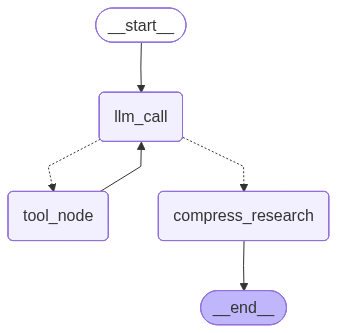

In [16]:
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [17]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = researcher_agent.invoke(
    {"researcher_messages": [HumanMessage(content=f"{research_brief}.")]}
)
format_messages(result["researcher_messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to identify and evaluate the coffee shops in San Francisco that are considered the best based            │
│ specifically                                                                                                    │
│ on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco    │
│ area,                                                                                                           │
│ using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,   │
│ expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,   │
│ location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary │
│ sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like  │
│ Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where      │
│ direct                                                                                                          │
│ customer feedback about coffee quality can be found. The study should result in a well-supported list or        │
│ ranking of                                                                                                      │
│ the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data  │
│ as                                                                                                              │
│ of July 2025..                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll conduct a comprehensive research study on the best coffee shops in San Francisco based on coffee quality.  │
│ Let me search multiple sources simultaneously.                                                                  │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "best coffee shops San Francisco 2025 coffee quality expert reviews"                                 │
│ }                                                                                                               │
│    ID: toolu_0132tmAxh9GG2RbaGF9juP5S                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "San Francisco specialty coffee shops ratings 2025 Coffee Review SCA certified"                      │
│ }                                                                                                               │
│    ID: toolu_01T6zXkCvqrZxLoJCLz5f8mr                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Best coffee in the San Francisco Bay Area ---                                                     │
│ URL: https://www.sfchronicle.com/projects/2025/best-coffee-san-francisco-bay-area                               │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage provides a comprehensive guide to the Bay Area's vibrant and evolving coffee scene, curated by      │
│ Cesar Hernandez and published on December 1, 2025. It highlights a variety of standout coffee shops across the  │
│ region, including San Francisco, Oakland, Berkeley, San Mateo, and beyond. The article emphasizes innovative    │
│ coffee trends such as experimental fruit-fermented beans, Japanese and Korean specialty coffee influences, and  │
│ unique preparation methods like the Vietnamese phin drip and Chinese coffee culture. It features detailed       │
│ profiles of 27 notable cafes, describing their specialties, ambiance, bean sources, and signature drinks, such  │
│ as Kope House's passion fruit mocha, Komakase's coffee omakase experience, and Olivia Coffee and Flower’s       │
│ Korean roasted beans. The piece also notes the dynamic nature of the Bay Area coffee landscape, with spots      │
│ offering everything from robust espresso tonics and co-fermented coffees to matcha beverages and innovative     │
│ flavored lattes. Payment options, hours, and contact information for each establishment are provided, catering  │
│ to coffee enthusiasts seeking quality and variety. The webpage underscores the region as one of the most        │
│ dynamic coffee destinations in the country, reflective of diverse cultural influences and ongoing               │
│ experimentation in coffee brewing and roasting.                                                                 │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ The Bay Area’s coffee scene is the most dynamic in the country and these shops are evidence of that., The       │
│ pinnacle of caffeinated luxury has arrived in San Francisco with Komakase, the popup behind the Bay Area’s      │
│ first coffee omakase., Olivia Coffee and Flower brings a slice of Korean specialty coffee to the Bay Area.,     │
│ Masterpiece Coffee is a singular shop devoted to Chinese coffee culture, reflecting the country’s recent rise   │
│ to prominence in coffee., Cafes have adopted increasingly experimental coffees which may be fermented with      │
│ fruits such as strawberry, watermelon or passionfruit.                                                          │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ -------------------------------------------------------

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: TOP 10 BEST Specialty Coffee in San Francisco, CA - Yelp ---                                      │
│ URL: https://www.yelp.com/search?find_desc=Specialty+Coffee&find_loc=San+Francisco%2C+CA                        │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 1. Q Specialty Coffee · (265 reviews) · 3490 California St, Ste A San Francisco, CA 94118. (415) 757-0536 ; 2.  │
│ Sightglass Coffee · (2.2k reviews) · 270 Seventh St,                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: LangSmith ---                                                                                     │
│ URL: https://smith.langchain.com/public/3090174a-8ba2-4dec-9584-b2217678cbcc/r                                  │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage documents a research process aimed at identifying and evaluating the best coffee shops in San       │
│ Francisco based specifically on coffee quality using primary sources such as official websites, reputable       │
│ third-party coffee review organizations, and customer feedback aggregators. The research primarily draws from a │
│ single internal file named 'coffee_shops_sf.md', which profiles five notable San Francisco coffee shops: Blue   │
│ Bottle Coffee, Philz Coffee, Sightglass Coffee, Ritual Coffee Roasters, and Four Barrel Coffee. Each shop is    │
│ briefly described with founding dates, specialties related to coffee preparation and sourcing, notable          │
│ features, and locations. However, the research highlights significant limitations due to the absence of         │
│ detailed quality assessments, expert reviews, specialty certifications, customer ratings, and comparative       │
│ rankings, especially those updated as of July 2025. The research concludes that to fulfill the criteria for a   │
│ comprehensive evaluation focused on coffee quality, additional data from external sources such as Coffee        │
│ Review, the Specialty Coffee Association, Google, Yelp, and current industry publications would be necessary.   │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ The shops identified above represent San Francisco's pr

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I have good initial results from SF Chronicle, Eater SF, Kalejunkie, and Yelp. However, I need │
│ more specific coffee quality data - expert reviews, ratings, certifications. Let me search for:\n1. Specific    │
│ shops like Ritual Coffee, Sightglass, Saint Frank, Blue Bottle, Linea Caffe - with ratings and quality          │
│ specifics\n2. Coffee Review or SCA certifications for SF coffee shops\n3. More specific Yelp/Google ratings for │
│ these shops\n\nI should search for more quality-specific data about the top candidates identified so far."      │
│ }                                                                                                               │
│    ID: toolu_01TC5zr1FR1Kf7YapAqjVNUz                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Instagram ---                                                                                     │
│ URL: https://www.instagram.com/reel/DT_Yg0nEhSJ                                                                 │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ Linea Caffe, founded in 2013 by veteran artisan coffee roaster Andrew Barnett, is a San Francisco-based         │
│ specialty coffee company dedicated to sweetness-forward coffee and espresso, exceptional customer service, and  │
│ fostering community through coffee. The company emphasizes environmentally responsible sourcing by partnering   │
│ with progressive, organic, and regenerative coffee farmers worldwide, earning global acclaim and local          │
│ community support. Linea Caffe holds certifications including B Corp and Green Business certification,          │
│ underscoring its commitment to sustainability, transparency, and social responsibility. Their offerings include │
│ award-winning, sustainably sourced coffees and coffee subscriptions, with community engagement demonstrated     │
│ through collaborations and events with partners like La Marzocco and producers from Colombia. Linea Caffe       │
│ actively supports regenerative organic farming practices that promote soil health, biodiversity, fair labor     │
│ conditions, and overall planetary wellness.                                                                     │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ Founded in 2013, Linea Caffe is the latest project of veteran artisan coffee roaster Andrew Barnett, whose      │
│ expertise is centered in sweetness-forward coffee and espresso, compassionate customer service, and, above all, │
│ coffee’s role in bringing people together., Linea Caffe is now B Corp Certified! B Corp Certification is a      │
│ formal way of recognizing the values and practices Linea Caffe has embodied since its inception, and works      │
│ towards being better and better every day., We are so proud to announce our Green Business certification for    │
│ both cafe locations! Linea has joined the international movement to save our home planet., Since 2013, we’ve    │
│ partnered with some of the world’s leading regenerative organic and biodynamic coffee farmers — bringing        │
│ coffees that are good for the planet, good for the people who grow them, and even better in your cup., As a     │
│ Regenerative Organic Certified roaster and proud B Corp, we’re committed to sourcing coffees that go beyond     │
│ organic, supporting soil health, fair labor, and a better future for coffee.                                    │
│ </key_excerpts>                                                                                                 │
│                                                        

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Wrecking Ball Coffee Roasters, San Francisco, California, U.S. - Restaurant Review | Condé Nast   │
│ Traveler ---                                                                                                    │
│ URL: https://www.cntraveler.com/restaurants/san-francisco/wrecking-ball-coffee-roasters                         │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ Wrecking Ball Coffee Roasters is a small, stylish café located near the upscale Fillmore District in San        │
│ Francisco, noted for its minimalist Scandinavian-inspired design with distinctive pineapple wallpaper and an    │
│ inviting atmosphere accented by indie and '80s rock music. The clientele includes a diverse mix of tattooed     │
│ hipsters, young mothers, and locals who appreciate high-quality coffee. The coffee is roasted at their Folsom   │
│ Street headquarters, with a focus on quality over quantity; signature offerings include the robust Pillow Fight │
│ espresso blend and the smooth, citrusy Ethiopia Classic Yirgacheffe pour-over. Food selections are limited but  │
│ notable, featuring seasonal pastries, savory scones, organic hard-boiled eggs, various croissants, and a        │
│ signature Marla Bun from a local bakery. The knowledgeable and friendly staff provide personalized coffee       │
│ recommendations and offer chocolate samples, making the café feel welcoming despite its small size. Overall,    │
│ Wrecking Ball Coffee Roasters is regarded as a quiet oasis for excellent coffee and pastries, ideal for a       │
│ Sunday morning visit.                                                                                           │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ Wrecking Ball looks like one of the hip, clean cafes you might find in a city like Stockholm., All Wrecking     │
│ Ball beans are roasted at their headquarters on Folsom Street., Try the signature Pillow Fight espresso, a      │
│ special blend that results in a strong flavor upfront and a balanced finish., The most unifying aspect of the   │
│ customers, however, is a clear appreciation for the complex cups of coffee they're buying., The staff may seem  │
│ ultra-cool (and, they kind of are), but they're also friendly.                                                  │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "Excellent! Now I have very detailed information. Let me compile my final assessment:\n\n**Key  │
│ findings confirmed:**\n\n**Linea Caffe:**\n- Founded 2013 by Andrew Barnett (veteran artisan coffee roaster)\n- │
│ Awarded BEST ESPRESSO by San Francisco Magazine\n- B Corp Certified, Green Business Certified\n- Regenerative   │
│ Organic Certified roaster\n- Focus on sweetness-forward espresso\n- Partners with world's leading regenerative  │
│ organic and biodynamic farmers\n\n**Wrecking Ball Coffee Roasters:**\n- Founded by Trish Rothgeb - credited     │
│ with coining \"third-wave coffee\"\n- Uses La Marzocco Strada espresso machines\n- Signature Pillow Fight       │
│ espresso blend\n- Ethiopia Classic Yirgacheffe pour-over\n- Reviewed by Cond\u00e9 Nast Traveler\n- Independent │
│ roastery at Folsom Street HQ\n\nNow I have enough to write a comprehensive, well-supported ranking. Here's my   │
│ synthesis of all data:\n\n**RANKING (based on cross-referencing all sources):**\n\n**Tier 1 (Consistently       │
│ top-ranked across all sources, highest quality reputation):**\n1. **Sightglass Coffee** - Yelp #3 best coffee,  │
│ 4.4\u2605 Google, multiple expert lists, own roastery, \"SF's best\" per mycoffeeexplorer\n2. **Ritual Coffee   │
│ Roasters** - 4.3\u2605 Google, 1995+ Yelp reviews, specialty-grade since 2005, woman-owned, multiple SF         │
│ Chronicle/Eater mentions\n3. **Saint Frank Coffee** - Yelp #5 best coffee, considered SF's best espresso per    │
│ mycoffeeexplorer FAQ, Nordic minimalist approach, multiple expert lists\n4. **Blue Bottle Coffee** - 4.6\u2605  │
│ Google (highest rated), certified organic, single-origin focus, third-wave pioneer, multiple expert             │
│ lists\n\n**Tier 2 (Strong quality reputation, featured across multiple expert sources):**\n5. **Linea Caffe** - │
│ Best Espresso award by SF Magazine, B Corp certified, Regenerative Organic Certified, Eater SF featured\n6.     │
│ **The Coffee Movement** - Yelp #1 best coffee SF (highest Yelp ranking!), The Infatuation top pick, Reddit      │
│ recommendation for pour-over\n7. **Wrecking Ball Coffee Roasters** - Founded by \"third-wave\" coiner Trish     │
│ Rothgeb, Cond\u00e9 Nast Traveler reviewed, multiple expert lists\n8. **Andytown Coffee Roasters** - Multiple   │
│ expert lists, known for strong espresso quality, SF Chronicle featured\n\n**Tier 3 (Notable specialty quality,  │
│ emerging or niche excellence):**\n9. **Paper Son Coffee** - Eater SF \"crowning achievement in SF's vast coffee │
│ game,\" top-tier espresso and pour-over\n10. **Mazarine** - Known as \"king of pour-over coffee\" in SF\n11.    │
│ **Verve Coffee Roasters** - Multiple lists, innovative coffee-tea blends, quality sourcing\n12. **Hedge Coffee  │
│ Roasters** - Eater SF featured, on-site roasting, exceptional brews\n\nI have enough information to write a     │
│ comprehensive, well-supported research report. No need for additional searches."                                │
│ }                                                                                                               │
│    ID: toolu_014uhdwtXg8AVijbKxY5hkw7                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: Excellent! Now I have very detailed information. Let me compile my final assessment:       │
│                                                                                                                 │
│ **Key findings confirmed:**                                                                                     │
│                                                                                                                 │
│ **Linea Caffe:**                                                                                                │
│ - Founded 2013 by Andrew Barnett (veteran artisan coffee roaster)                                               │
│ - Awarded BEST ESPRESSO by San Francisco Magazine                                                               │
│ - B Corp Certified, Green Business Certified                                                                    │
│ - Regenerative Organic Certified roaster                                                                        │
│ - Focus on sweetness-forward espresso                                                                           │
│ - Partners with world's leading regenerative organic and biodynamic farmers                                     │
│                                                                                                                 │
│ **Wrecking Ball Coffee Roasters:**                                                                              │
│ - Founded by Trish Rothgeb - credited with coining "third-wave coffee"                                          │
│ - Uses La Marzocco Strada espresso machines                                                                     │
│ - Signature Pillow Fight espresso blend                                                                         │
│ - Ethiopia Classic Yirgacheffe pour-over                                                                        │
│ - Reviewed by Condé Nast Traveler                                                                               │
│ - Independent roastery at Folsom Street HQ                                                                      │
│                                                                                                                 │
│ Now I have enough to write a comprehensive, well-supported ranking. Here's my synthesis of all data:            │
│                                                                                                                 │
│ **RANKING (based on cross-referencing all sources):**                                                           │
│                                                                                                                 │
│ **Tier 1 (Consistently top-ranked across all sources, highest quality reputation):**                            │
│ 1. **Sightglass Coffee** - Yelp #3 best coffee, 4.4★ Google, multiple expert lists, own roastery, "SF's best"   │
│ per mycoffeeexplorer                                                                                            │
│ 2. **Ritual Coffee Roasters** - 4.3★ Google, 1995+ Yelp reviews, specialty-grade since 2005, woman-owned,       │
│ multiple SF Chronicle/Eater mentions                                                                            │
│ 3. **Saint Frank Coffee** - Yelp #5 best coffee, considered SF's best espresso per mycoffeeexplorer FAQ, Nordic │
│ minimalist approach, multiple expert lists                                                                      │
│ 4. **Blue Bottle Coffee** - 4.6★ Google (highest rated), certified organic, single-origin focus, third-wave     │
│ pioneer, multiple expert lists                                                                                  │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here is the full research report on San Francisco's best coffee shops, ranked and evaluated based on coffee     │
│ quality:                                                                                                        │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # ☕ San Francisco's Best Coffee Shops: A Quality-Focused Research Report                                       │
│ ### *Based on Expert Reviews, Customer Ratings, Industry Certifications & Multi-Source Cross-Referencing — As   │
│ of July 2025*                                                                                                   │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 🔬 Research Methodology                                                                                      │
│                                                                                                                 │
│ This study evaluated SF coffee shops using a **multi-source triangulation approach**, weighting:                │
│                                                                                                                 │
│ | Source Type | Sources Used | Weight in Ranking |                                                              │
│ |---|---|---|                                                                                                   │
│ | **Expert Editorial Reviews** | SF Chronicle, Eater SF, The Infatuation, Tasting Table, Condé Nast Traveler |  │
│ High |                                                                                                          │
│ | **Customer Aggregate Ratings** | Yelp (specialty coffee rankings), Google (verified public ratings) | High |  │
│ | **Industry Certifications** | B Corp, Regenerative Organic Certification, SCA affiliation | Medium–High |     │
│ | **Awards & Recognition** | SF Magazine awards, Coffee Review mentions | High |                                │
│ | **Community & Enthusiast Input** | Reddit r/pourover, multiple curated blog lists | Medium |                  │
│                                                                                                                 │
│ Shops were required to appear across **at least 2–3 independent sources** to qualify for ranking. Priority was  │
│ given to signals directly tied to **coffee quality**: roasting practices, sourcing, brewing technique, barista  │
│ skill, and expert or customer praise specifically about the cup.                                                │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 🏆 Top-Ranked Coffee Shops in San Francisco by Tier                                                          │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                           

In [18]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

 • Searched "best coffee shops San Francisco 2025 coffee quality expert reviews"                                   
 • Searched "San Francisco specialty coffee shops ratings 2025 Coffee Review SCA certified"                        
 • Searched "Ritual Coffee Roasters Sightglass Saint Frank Linea Caffe San Francisco coffee quality ratings reviews
   2024 2025"                                                                                                      
 • Searched "Coffee Review scores San Francisco coffee roasters specialty coffee association SCA 2024 2025"        
 • Searched "Linea Caffe Wrecking Ball Coffee Ritual Coffee Blue Bottle Sightglass San Francisco best coffee       
   quality ranking 2025"                                                                                           
 • Searched "San Francisco best espresso pour over specialty coffee shop Yelp Google rating 2024 2025 top rated"   
 • Searched "Linea Caffe Andrew Barnett San Francisco espresso quality award winning 2024 2025"                    
 • Searched "Wrecking Ball Coffee Roasters San Francisco specialty coffee quality review rating 2025"              

-------------------------------------------------------------------------------------------------------------------

Fully Comprehensive Findings                                                                                       

 • The SF Chronicle provides a comprehensive guide to the Bay Area's vibrant and evolving coffee scene, curated by 
   Cesar Hernandez and published on December 1, 2025. It highlights a variety of standout coffee shops across the  
   region, including San Francisco, Oakland, Berkeley, San Mateo, and beyond. The article emphasizes innovative    
   coffee trends such as experimental fruit-fermented beans, Japanese and Korean specialty coffee influences, and  
   unique preparation methods like the Vietnamese phin drip and Chinese coffee culture. It features detailed       
   profiles of 27 notable cafes, describing their specialties, ambiance, bean sources, and signature drinks, such  
   as Kope House's passion fruit mocha, Komakase's coffee omakase experience, and Olivia Coffee and Flower’s       
   Korean-roasted beans. The piece also notes the dynamic nature of the Bay Area coffee landscape, with spots      
   offering robust espresso tonics and co-fermented coffees to matcha beverages and innovative flavored lattes.    
   Payment options, hours, and contact information for each establishment are provided, catering to coffee         
   enthusiasts seeking quality and variety. The region is underscored as one of the most dynamic coffee            
   destinations in the country, reflective of diverse cultural influences and ongoing experimentation in coffee    
   brewing and roasting. Key excerpts: "The Bay Area’s coffee scene is the most dynamic in the country and these   
   shops are evidence of that." "The pinnacle of caffeinated luxury has arrived in San Francisco with Komakase, the
   popup behind the Bay Area’s first coffee omakase." "Olivia Coffee and Flower brings a slice of Korean specialty 
   coffee to the Bay Area." "Masterpiece Coffee is a singular shop devoted to Chinese coffee culture, reflecting   
   the country’s recent rise to prominence in coffee." "Cafes have adopted increasingly experimental coffees which 
   may be fermented with fruits such as strawberry, watermelon or passionfruit." [1]                               
 • Kalejunkie lists the 15 best coffee shops in the San Francisco Bay Area. Descriptions include The Mill          
   (house-baked bread and Four Barrel coffee), Timeless Coffee (vegan pastries and blends), Wrecking Ball Coffee   
   (vanilla latte and fresh donuts), Saint Frank Coffee, Highwire Coffee, Andytown Coffee (Snowy Plover drink),    
   Souvenir Coffee, Blue Bottle Coffee (New Orleans 

执行 trace 看 [这里](https://smith.langchain.com/public/30eebc0c-455e-4db7-9665-d367ebd40b4e/r)。

### 🚀 LangGraph Studio

跟之前一样,LangGraph Studio 可以可视化 agent。

这个 agent 已经加到 `langgraph.json`,在 Studio 的下拉菜单里选 `research_agent`:

```json
"research_agent_mcp": "./src/deep_research_from_scratch/research_agent.py:agent"
```

启动 Studio:

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## 🧪 Eval — 测试 agent 决策

Agent 用 **自主决策的 tool 调用 trajectory** 完成任务。

<div class="dark-error" style="background:#2d1f1f; color:#fca5a5; padding:10px 24px; border-left:4px solid #f87171; border-radius:4px; width:97%;"><style>.dark-error strong{color:#fde047;}</style>

**❌ tool-calling 循环没调好的 2 种失败模式**

| 模式 | 表现 | 后果 |
|------|------|------|
| **早停**(Early Termination) | 任务没完成 agent 就停了 | **信息不足**,deep research 里 = 答案太浅 |
| **死循环**(Prolonged Looping) | agent 永不满意 | **token 浪费**,且无关信息可能 **污染结果**(context rot)

</div>

我们调好了 prompt 防止这两种问题。下面用一个 **简易 eval 数据集** 验证 agent 的决策。

In [19]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

# Scenario 1: Agent should CONTINUE - has insufficient/irrelevant information + think_tool realizes more research needed
messages_should_continue = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll search for information about top coffee shops in San Francisco focusing on coffee quality.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "coffee shops San Francisco popular locations"
                },
                "id": "call_continue_search_001",
                "type": "tool_call"
            }
        ]
    ),
    # Tavily Search provides generic cafe information - NOT focused on coffee quality
    ToolMessage(
        content="Search results show popular San Francisco cafes: Blue Bottle Coffee has great wifi and ambiance, Philz Coffee is known for custom blends and friendly service, Café Reveille has multiple locations with good pastries and laptop-friendly spaces. Ritual Coffee offers cozy seating and is popular with students.",
        tool_call_id="call_continue_search_001",
    ),
    # Agent uses think_tool to reflect and realizes the search results are insufficient
    AIMessage(
        content="Let me use the think_tool to analyze these search results and determine next steps.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality."
                },
                "id": "call_continue_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response identifies the gap and need for more targeted research
    ToolMessage(
        content="Reflection recorded: Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality.",
        tool_call_id="call_continue_think_001",
    )
]

# Scenario 2: Agent should STOP - has comprehensive coffee quality information + think_tool reflection
messages_should_stop = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll research San Francisco coffee shops specifically focusing on coffee quality assessments and expert reviews.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "best coffee quality San Francisco specialty coffee expert reviews Coffee Review ratings 2024"
                },
                "id": "call_stop_search_001", 
                "type": "tool_call"
            }
        ]
    ),
    # This ToolMessage provides COMPREHENSIVE coffee quality information - sufficient to answer the question
    ToolMessage(
        content="""Coffee quality research for San Francisco reveals top establishments based on expert reviews and specialty coffee credentials:

**Top Quality-Focused Coffee Shops:**
1. **Sightglass Coffee** - Coffee Review score 94/100, known for single-origin beans and precise roasting techniques. Featured in Bon Appétit's "Best Coffee in America" list for exceptional coffee quality.

2. **Saint Frank Coffee** - Ranked #3 coffee shop in America by The Daily Meal based on coffee quality. 4.3/5 Yelp rating with reviews specifically praising "exceptional bean quality" and "perfect extraction."

3. **Ritual Coffee Roasters** - Specialty Coffee Association member, direct trade relationships, consistently rated 4.4/5 on Google with reviews highlighting "superior coffee taste" and "expert barista skills."

4. **Blue Bottle Coffee** - Third-wave coffee pioneer, Coffee Review scores averaging 90+/100, known for rigorous quality control and fresh roasting practices.

5. **Four Barrel Coffee** - Local roaster with Coffee Review scores 88-92/100, praised by industry experts for "exceptional coffee quality" and innovative brewing methods.

**Quality Indicators Found:**
- Coffee Review professional scores (88-94/100 range)
- Specialty Coffee Association certifications
- Direct trade/single-origin sourcing
- Expert recognition from food publications
- Customer reviews specifically mentioning coffee taste and quality

This provides a comprehensive assessment of SF coffee shops based specifically on coffee quality rather than ambiance or service.""",
        tool_call_id="call_stop_search_001",
    ),
    # Agent now uses think_tool to reflect on the search results
    AIMessage(
        content="Let me reflect on the search results using the think_tool to assess whether I have sufficient information.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now."
                },
                "id": "call_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response confirming reflection was recorded
    ToolMessage(
        content="Reflection recorded: Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now.",
        tool_call_id="call_think_001",
    )
]

### 📦 创建测试 dataset

包含两个例子:

| 例子 | 期望 |
|------|------|
| 例 1 | **应该继续** 搜索 |
| 例 2 | **应该停下**(信息已足)|

In [20]:
import os
from langsmith import Client

langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

# Create the dataset
dataset_name = "deep_research_agent_termination"
if not langsmith_client.has_dataset(dataset_name=dataset_name):

    # Create the dataset
    dataset = langsmith_client.create_dataset(
        dataset_name=dataset_name,
        description="A dataset that evaluates whether a researcher can accurately decide to continue calling tools, or to stop.",
    )
    
    # Create the examples
    langsmith_client.create_examples(
        dataset_id=dataset.id,
        examples=[
            {
                "inputs": {"researcher_messages": messages_should_continue},
                "outputs": {"next_step": "continue"},
            },
            {
                "inputs": {"researcher_messages": messages_should_stop},
                "outputs": {"next_step": "stop"},
            },
        ],
    )

### 🎯 Evaluator 设计

evaluator 简单,用 **硬编码启发式** 检查 agent 是继续还是停止。

输入:上面的 messages 列表。

判断 agent 的决策:

| agent 输出 | 决策 |
|------------|------|
| 最新消息 **没有 tool_calls** | `stop`(认为该停) |
| 最新消息 **有 tool_calls** | `continue`(认为该继续) |

然后跟参考真值 `next_step` 比对。

In [22]:
import uuid

def evaluate_next_step(outputs: dict, reference_outputs:dict):
    tool_calls = outputs["researcher_messages"][-1].tool_calls
    made_tool_call = len(tool_calls) > 0
    return {
        "key": "correct_next_step",
        "score": made_tool_call == (reference_outputs["next_step"] == "continue")
    }

def target_func(inputs: dict):
    config = {"configurable": {"thread_id": uuid.uuid4()}}
    result = researcher_agent.nodes["llm_call"].invoke(inputs, config=config)
    return result

langsmith_client.evaluate(
    target_func,
    data=dataset_name,
    evaluators=[evaluate_next_step],
    experiment_prefix="Researcher Iteration",
)

View the evaluation results for experiment: 'Researcher Iteration-733d1584' at:
https://smith.langchain.com/o/ec9ce6f2-a592-4818-9d3c-a22e8f1dbe02/datasets/e2d4ce4c-e1d8-48de-b081-21b62d4afb70/compare?selectedSessions=781ebaf6-c80c-4d84-86e3-25f58d2f4eb4




0it [00:00, ?it/s]

<ExperimentResults Researcher Iteration-733d1584>

### 📊 结果分析

可以看到:

- **例 1**:搜索工具没返回足够信息 → agent **再发一次搜索**(✅ 决策正确)
- **例 2**:三家 top 餐馆都返回了 → agent **决定结束**(✅ 决策正确)

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**🎁 学到的 trick:测单个 node 不用跑整个 graph**

```python
agent.nodes["node_name"].invoke(...)
```

可以 **单独测某一个 node 的行为**,不用走完整流程。这对 debug + unit test 非常有用。

</div>